# Environment

In [1]:
library(dplyr)
library(DBI)
library(RSQLite)
library(sf)
library(spdep)
library(sp)
library(tidyverse)
library(grf)
library(spatialRF)
library(arrow)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"package 'RSQLite' was built under R version 4.5.2"
Linking to GEOS 3.13.1, GDAL 3.11.0, PROJ 9.6.0; sf_use_s2() is TRUE

Loading required package: spData

To access larger datasets in this package, install the spDataLarge
package with: `install.packages('spDataLarge',
repos='https://nowosad.github.io/drat/', type='source')`

Warning message:
"package 'tidyverse' was built under R version 4.5.2"
Warning message:
"package 'readr' was built under R version 4.5.2"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ readr     2.1.6
✔ ggplot2   4.0.0     ✔ stringr   1.5.2
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts

# Loading data

In [2]:
repo_path <- dirname(file.path(getwd()))
list_of_columns <- c(
  'gdf_rho_0_1', 'gdf_rho_0_15', 'gdf_rho_0_2',
  'gdf_rho_0_25', 'gdf_rho_0_3', 'gdf_rho_0_35',
  'gdf_rho_0_4', 'gdf_rho_0_45', 'gdf_rho_0_5', 'gdf_rho_0_55'
)

con <- dbConnect(
  RSQLite::SQLite(),
  paste0(repo_path, "/03_simulated_data/simulated_data.sqlite")
)

dict_geom_sf <- setNames(
  lapply(list_of_columns, function(layer) {

    geom_df <- dbReadTable(con, layer)

    geom <- st_as_sfc(geom_df$GEOMETRY, EWKB = TRUE)

    sf_obj <- st_sf(
      geom_df[, setdiff(names(geom_df), c("geometry", "GEOMETRY", "ogc_fid"))],
      geometry = geom
    )

    st_crs(sf_obj) <- 3857
    geom_df2 <- geom_df[, !(names(geom_df) %in% c("GEOMETRY", "ogc_fid"))]

    return(list(
      sf = sf_obj,
      df = geom_df2
    ))
  }),
  list_of_columns
)

dbDisconnect(con)

# Distance matrix

In [3]:
centroids <- sf::st_centroid(dict_geom_sf$gdf_rho_0_1$sf)

distance_matrix <- units::drop_units(
  as.matrix(sf::st_distance(centroids))
)

# Preparing and saving spatial predictors

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            12
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.4289193
  - R squared (cor(obs, pred)^2):     0.9360294
  - Pseudo R squared (cor(obs, pred)):0.9674861
  - RMSE (oob):                       0.9499201
  - RMSE:                             0.4119
  - Normalized RMSE:                  0.2477819

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.51 │  -0.26 │ 

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            11
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.4924157
  - R squared (cor(obs, pred)^2):     0.9428035
  - Pseudo R squared (cor(obs, pred)):0.9709807
  - RMSE (oob):                       0.9251855
  - RMSE:                             0.402
  - Normalized RMSE:                  0.2468509

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.21 │  -0.26 │  

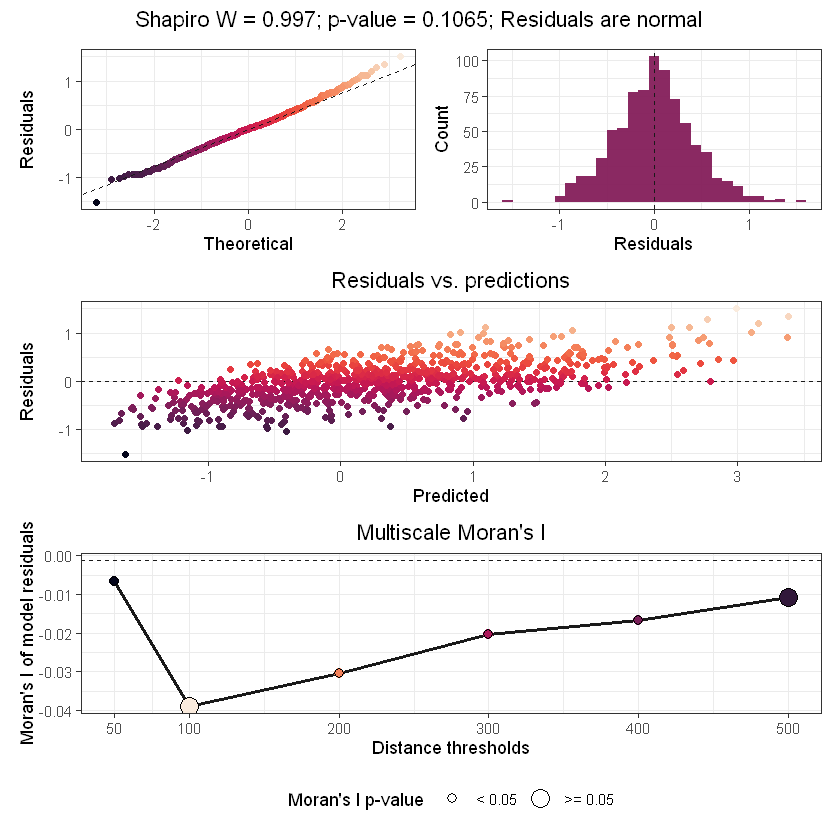

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            11
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.4972533
  - R squared (cor(obs, pred)^2):     0.9424356
  - Pseudo R squared (cor(obs, pred)):0.9707912
  - RMSE (oob):                       0.9306848
  - RMSE:                             0.4042
  - Normalized RMSE:                  0.2420289

Model residuals 
  - Stats: 
              ┌───────┬────────┬────────┬───────┬────────┬──────┐
              │ Min.  │ 1st Q. │ Median │ Mean  │ 3rd Q. │ Max. │
              ├───────┼────────┼────────┼───────┼────────┼──────┤
              │ -1.23 │  -0.25 │  

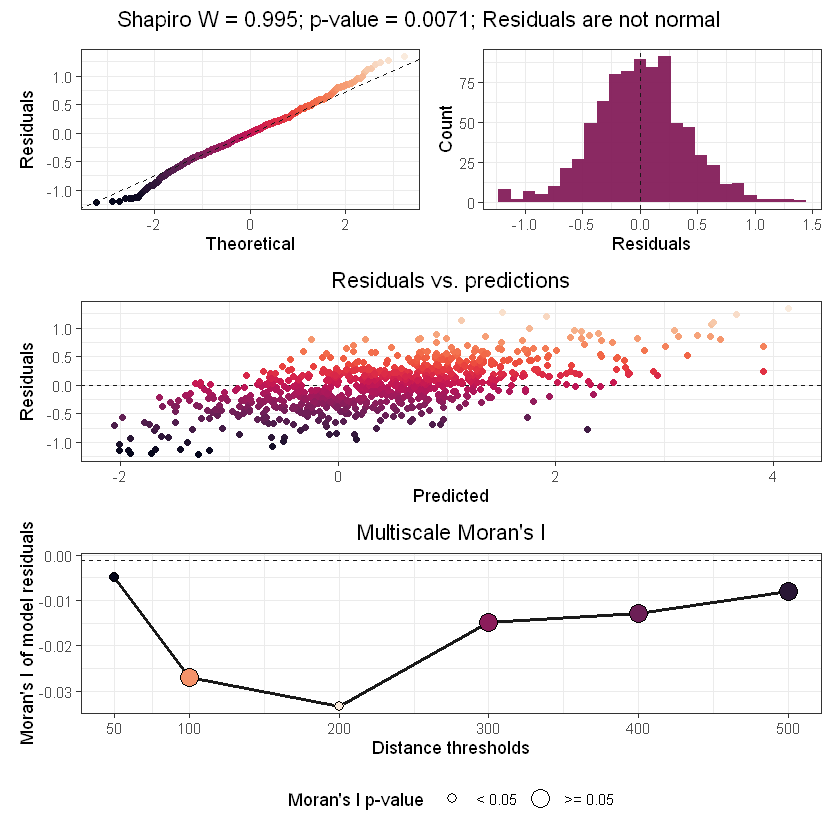

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            11
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5067111
  - R squared (cor(obs, pred)^2):     0.94377
  - Pseudo R squared (cor(obs, pred)):0.9714782
  - RMSE (oob):                       0.9337151
  - RMSE:                             0.4056
  - Normalized RMSE:                  0.2432901

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.20 │  -0.26 │  -

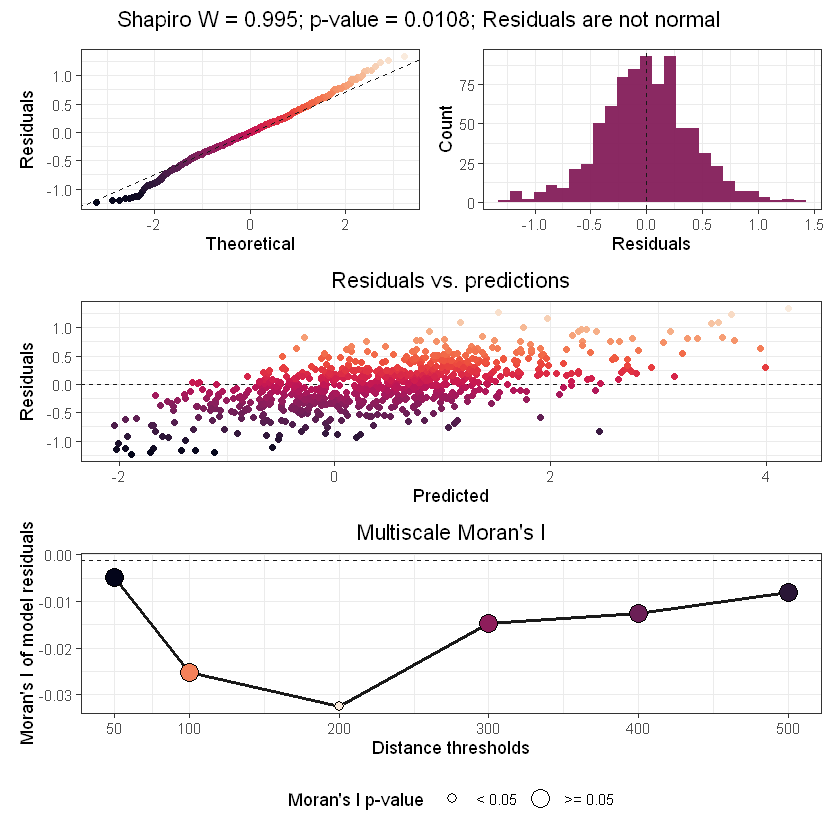

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            11
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5230154
  - R squared (cor(obs, pred)^2):     0.9449045
  - Pseudo R squared (cor(obs, pred)):0.972062
  - RMSE (oob):                       0.9322021
  - RMSE:                             0.4047
  - Normalized RMSE:                  0.2372271

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.22 │  -0.26 │  

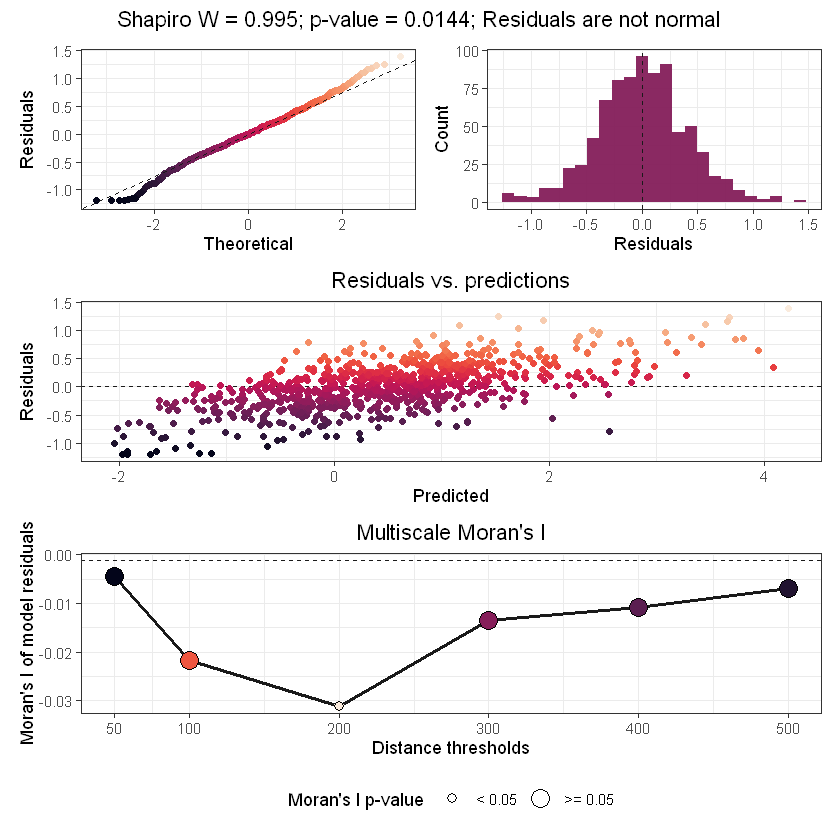

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            11
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5349771
  - R squared (cor(obs, pred)^2):     0.9458521
  - Pseudo R squared (cor(obs, pred)):0.9725493
  - RMSE (oob):                       0.937291
  - RMSE:                             0.4063
  - Normalized RMSE:                  0.2335437

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.26 │  -0.26 │  

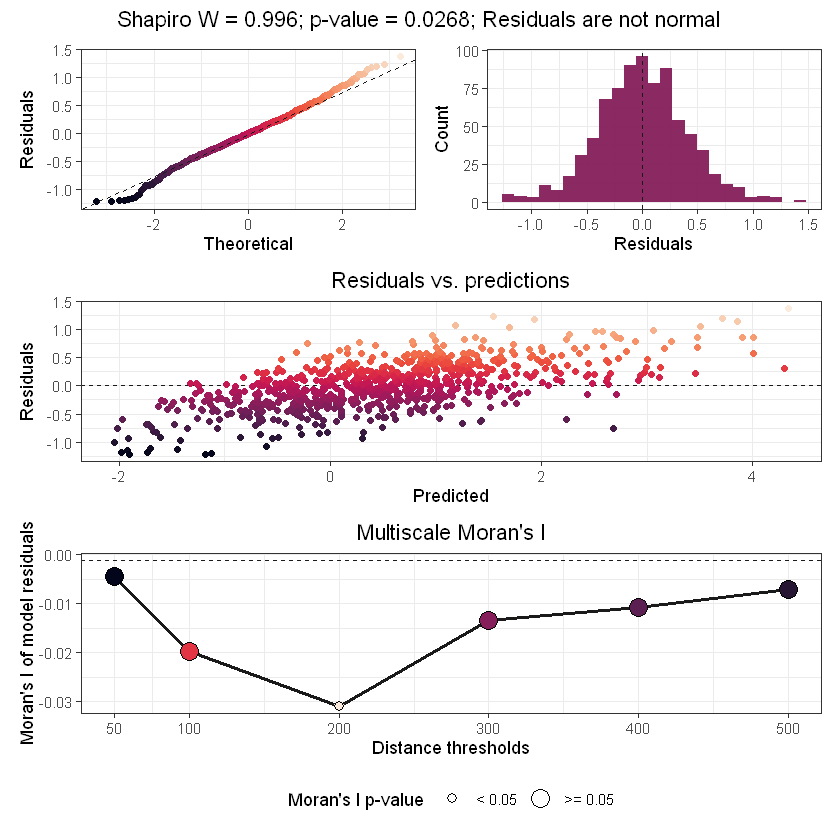

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            11
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5505454
  - R squared (cor(obs, pred)^2):     0.946873
  - Pseudo R squared (cor(obs, pred)):0.973074
  - RMSE (oob):                       0.9417576
  - RMSE:                             0.4095
  - Normalized RMSE:                  0.2321337

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.25 │  -0.25 │  -

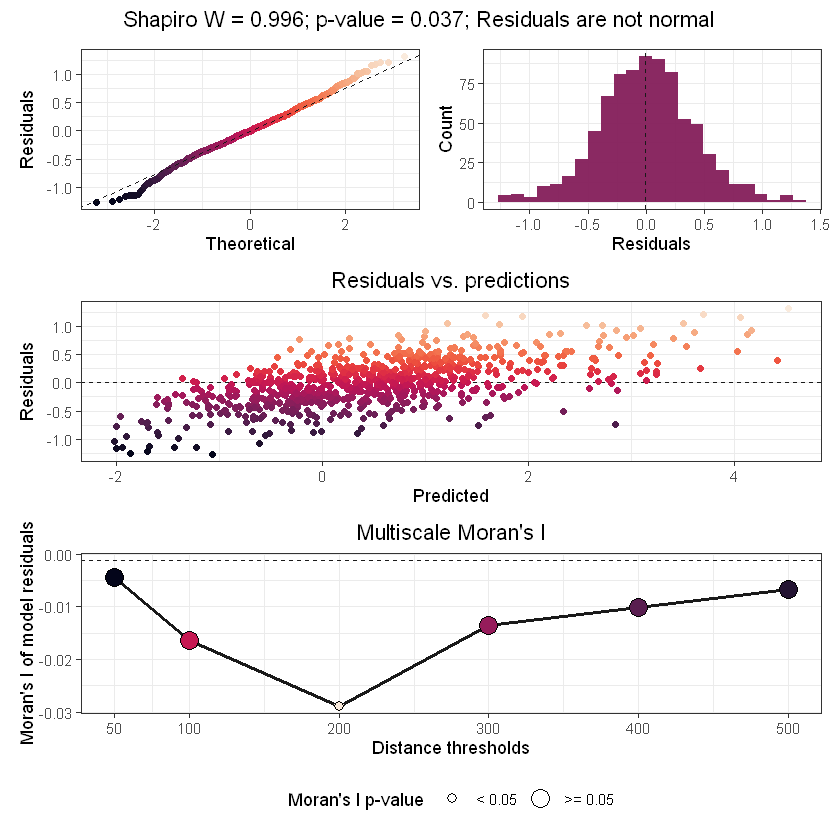

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            11
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5694018
  - R squared (cor(obs, pred)^2):     0.9489635
  - Pseudo R squared (cor(obs, pred)):0.9741476
  - RMSE (oob):                       0.9463609
  - RMSE:                             0.4109
  - Normalized RMSE:                  0.2299364

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.25 │  -0.26 │ 

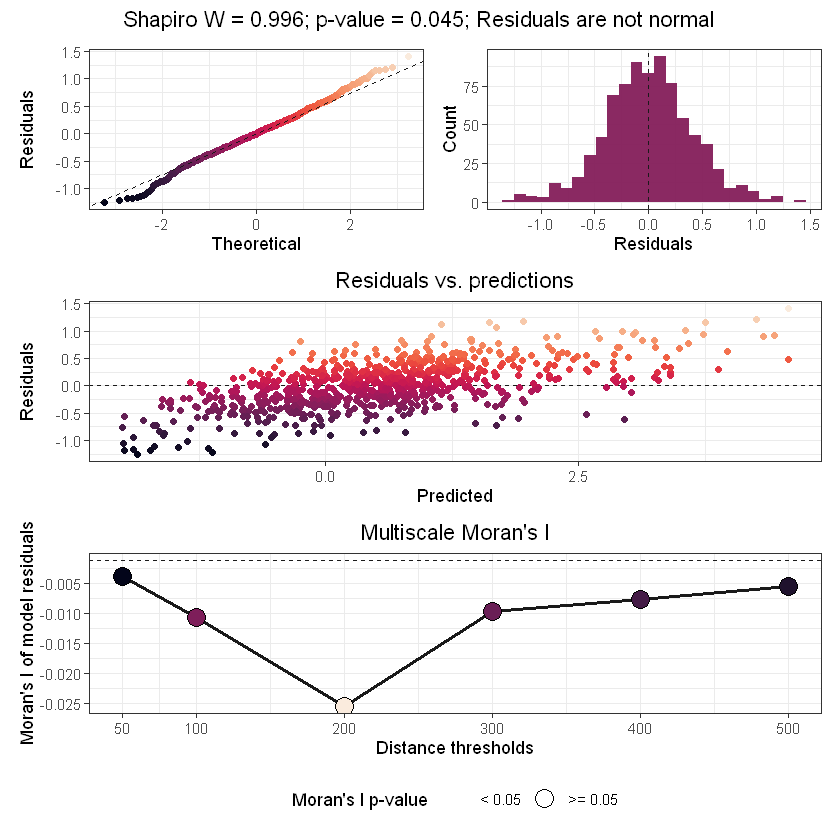

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            11
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5878685
  - R squared (cor(obs, pred)^2):     0.9503148
  - Pseudo R squared (cor(obs, pred)):0.9748409
  - RMSE (oob):                       0.9559607
  - RMSE:                             0.4152
  - Normalized RMSE:                  0.228861

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.30 │  -0.27 │  

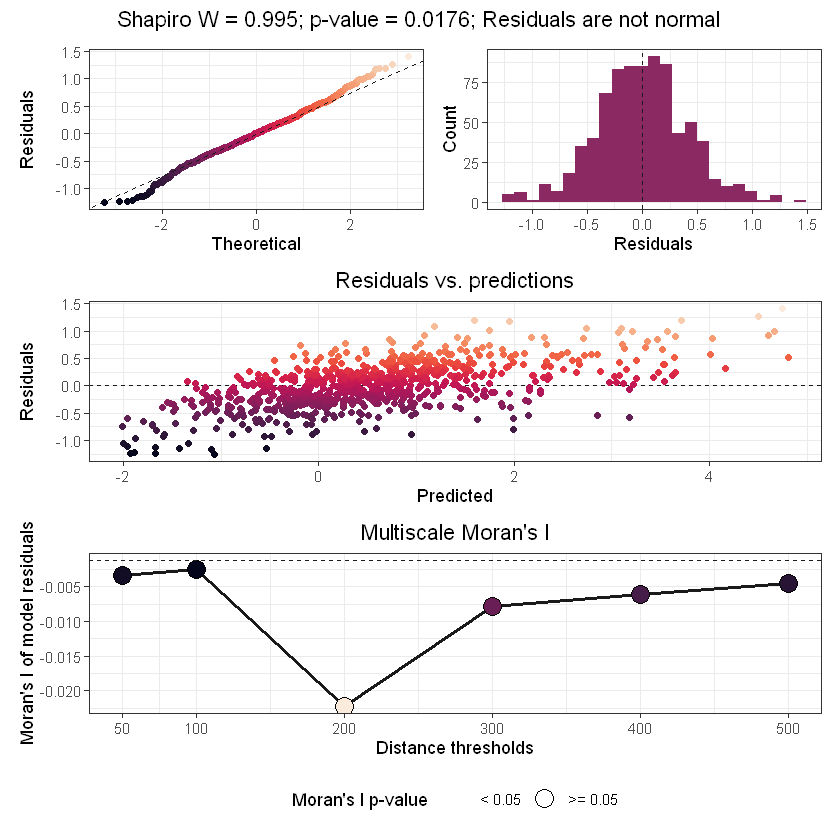

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            11
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.6098028
  - R squared (cor(obs, pred)^2):     0.9519246
  - Pseudo R squared (cor(obs, pred)):0.9756662
  - RMSE (oob):                       0.9674527
  - RMSE:                             0.4202
  - Normalized RMSE:                  0.2271719

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.28 │  -0.26 │ 

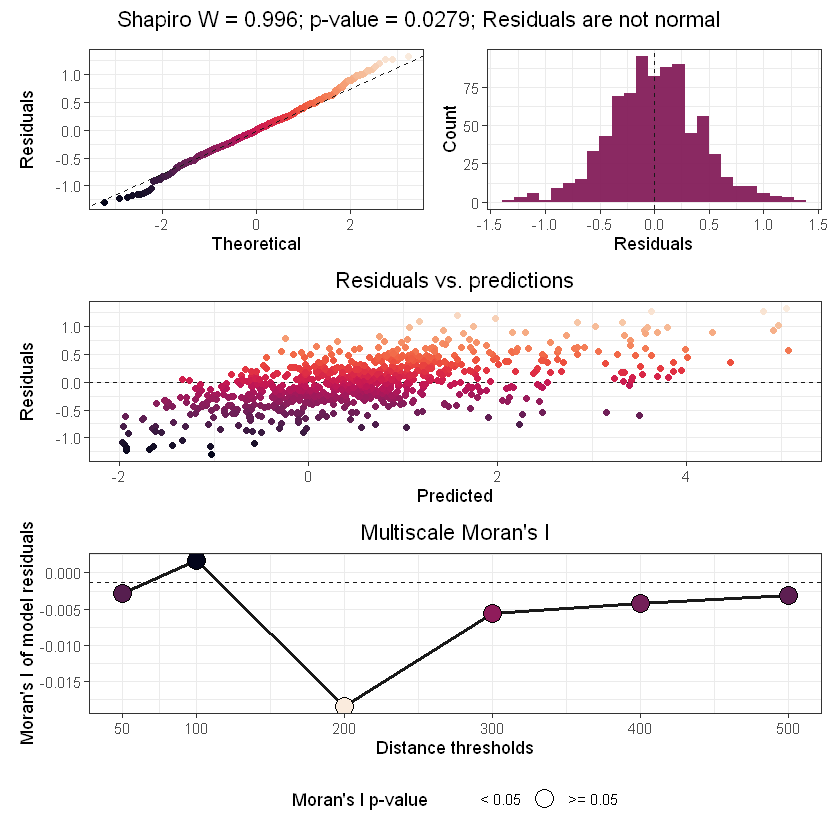

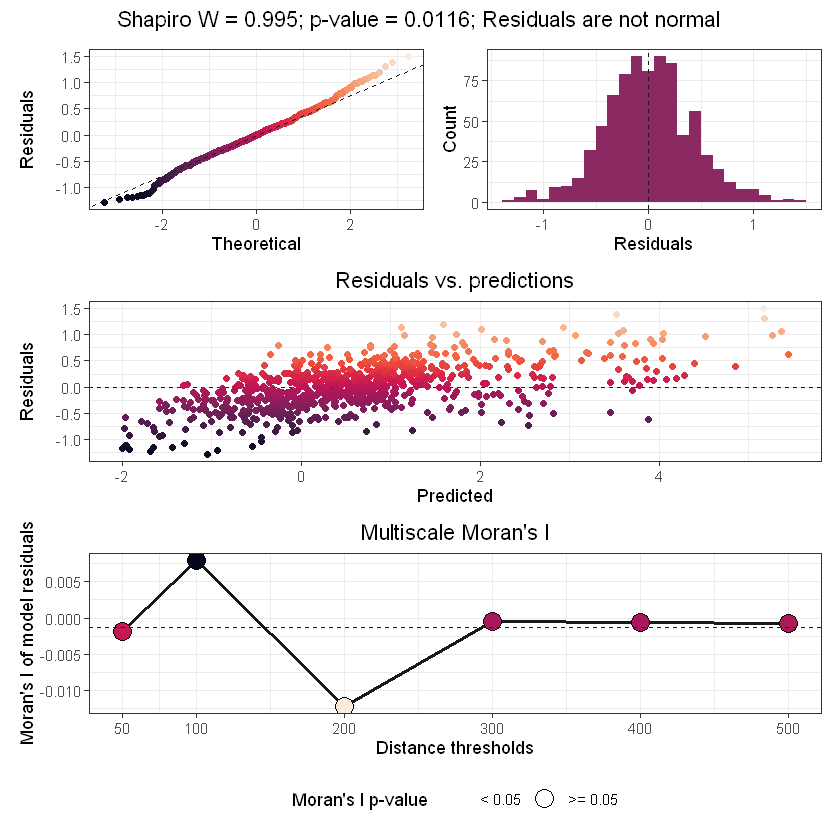

In [5]:
con <- dbConnect(
  RSQLite::SQLite(),
  paste0(repo_path, "/03_simulated_data/simulated_data.sqlite")
)

for (layer in list_of_columns) {

  df1 <- dict_geom_sf[[layer]]$df

  model <- spatialRF::rf_spatial(
    data = df1,
    dependent.variable.name = "y",
    predictor.variable.names = c('c1', 'c2'),
    distance.matrix = distance_matrix,
    distance.thresholds = c(50, 100, 200, 300, 400, 500)
  )

  spatial_predictors_df <- spatialRF::get_spatial_predictors(model)

  df3 <- cbind(df1, spatial_predictors_df)

  dbWriteTable(
    con,
    paste0(layer, "_sp"),
    df3,
    overwrite = TRUE
  )
}

dbDisconnect(con)